# Hamiltoniano SSH
Consideremos una celda unidad de dos transmon con parámetros iguales y un acoplamiento $g = \nu$ y cada celda unidad acoplada a la siguiente con un acoplamiento $g = w$, el hamiltoniano (sin el término no lineal de orden 4) es
$$
\hat H = \sum_{j, \sigma}\left( \hbar \omega_q \hat b_{j, \sigma}^\dag \hat b_{j, \sigma} - U\left(\hat b_{j, \sigma}^2 + (\hat b_{j, \sigma}^\dag)^2 + (\hat b_{j, \sigma}^\dag\hat b_{j, \sigma}^\dag\hat b_{j, \sigma}\hat b_{j, \sigma})\right)\right) - \hbar \nu \sum_j (\hat b_{j, A}^\dag - \hat b_{j, A})(\hat b_{j, B}^\dag - \hat b_{j, B}) - \hbar w\sum_j(\hat b_{j, B}^\dag - \hat b_{j, B})(\hat b_{j+1, A}^\dag - \hat b_{j+1, A}) 
$$
con $U = 6\hbar \lambda$ y $\sigma = \{A, B\}$. Pasando a espacio $k$, tenemos que
$$
\hat H = \sum_{k, \sigma}\left[ \hbar \omega_q \hat b^\dag_{k, \sigma} \hat b_{k, \sigma} + U\left(\hat b_{k, \sigma}^\dag \hat b_{-k, \sigma}^\dag + \hat b_{k, \sigma} \hat b_{-k, \sigma} + \right)\right] + \sum_k\left[\Delta_k \hat b_{k, A}^\dag \hat b_{k, B} + \Delta_k^* \hat b_{k, B}^\dag \hat b_{k, A}\right] - \sum_k\left[\Delta_k \hat b^\dag_{k, A} \hat b^\dag_{-k, B} + \Delta_k^* \hat b_{k, A} \hat b_{-k, B}\right] - \frac{U}{N}\sum_{p,\,q\,r\,s\,\sigma} \delta_{p + q}^{r + s} \hat b^\dag_p \hat b^\dag_q \hat b_r \hat b_s
$$
con $\Delta_k = \hbar(\nu + w e^{-ik})$. Por medio de una transformación de Bogoliubov, despreciando el término de interacción se diagonaliza el hamiltoniano y se obtiene
$$
\hat H = \sum_k \left[E_+(k)\hat \alpha_k^\dag \hat \alpha_k + E_{-}(k) \hat \beta_k^\dag \hat \beta_k\right] + \text{const.} 
$$
con $\alpha_k,\, \beta_k$ operadores bosónicos dados por
$$
\hat \alpha_k = \frac{\cosh \theta_+}{\sqrt{2}}(\hat b_{kA} + \hat b_{kB}) - \frac{\sinh \theta_+}{\sqrt{2}}(\hat b^\dag_{-k A} + \hat b^\dag_{-k B})
$$
$$
\hat \beta_k = \frac{\cosh \theta_-}{\sqrt{2}}(\hat b_{kA} - \hat b_{kB}) - \frac{\sinh \theta_+}{\sqrt{2}}(\hat b^\dag_{-k A} - \hat b^\dag_{-k B})
$$
con $\tanh \theta_\pm = \frac{2U \pm \vert \Delta_k \vert}{\hbar \omega_q \pm \vert \Delta_k \vert+E_\pm}$ y energías dadas por
$$
E_\pm(k) = \sqrt{(\hbar \omega_q)^2 - 4U^2} \cdot \sqrt{1 \pm \frac{2 \vert \Delta_k \vert}{\hbar \omega_q + 2U}}
$$
En esta notación se puede encontrar que la parte diagonal en la base de Fock definida por $\alpha_k$ y $\beta_k$ del término de interacción puede darse por medio de un hamitloniano efectivo de Kerr dado por

$$H_\text{eff} = \frac{U}{N} \Bigg\{$$

$$-4\!\left(\sum_k f_k\left(\hat{n}_{\alpha k}+\tfrac{1}{2}\right)\right)\!\left(\sum_q (f_q+g_q)\left(\hat{n}_{\beta q}+\tfrac{1}{2}\right)\right)$$

$$-4\!\left(\sum_k g_k\left(\hat{n}_{\beta k}+\tfrac{1}{2}\right)\right)\!\left(\sum_q (f_q+g_q)\left(\hat{n}_{\alpha q}+\tfrac{1}{2}\right)\right)$$

$$-\left(\sum_k \cosh^2\!\theta^+_k\,\hat{n}_{\alpha k}\right)\!\left(\sum_q \sinh^2\!\theta^+_q\left(\hat{n}_{\alpha q}+1\right)\right) - \left(\sum_k \cosh^2\!\theta^-_k\,\hat{n}_{\beta k}\right)\!\left(\sum_q \sinh^2\!\theta^-_q\left(\hat{n}_{\beta q}+1\right)\right)$$

$$+\sum_k\left[f_k^2\!\left(\hat{n}_{\alpha k}+\tfrac{1}{2}\right) + g_k^2\!\left(\hat{n}_{\beta k}+\tfrac{1}{2}\right)\right] \Bigg\}$$

donde $f_k = \sinh(2\theta^+_k)/2 = (2U+|\Delta_k|)/(2E^+_k)$ y $g_k = \sinh(2\theta^-_k)/2 = (2U-|\Delta_k|)/(2E^-_k)$. 

# Bandas de energía analíticas en el  modelo SSH

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.special import genlaguerre, gammaln
import itertools
import scienceplots
plt.style.use(['science', 'notebook'])


def ssh_energies(band, omega_q, nu, w, U, k):
    delta = np.sqrt(nu**2 + w**2 + 2 * nu * w * np.cos(k))
    if band == 0:
        energy = np.sqrt((omega_q)**2 - 4*U**2) * np.sqrt(1 + 2 * delta / (omega_q - 2 * U))
    elif band == 1:
        energy = np.sqrt((omega_q)**2 - 4*U**2) * np.sqrt(1 - 2 * delta / (omega_q - 2 * U))
        
    return energy


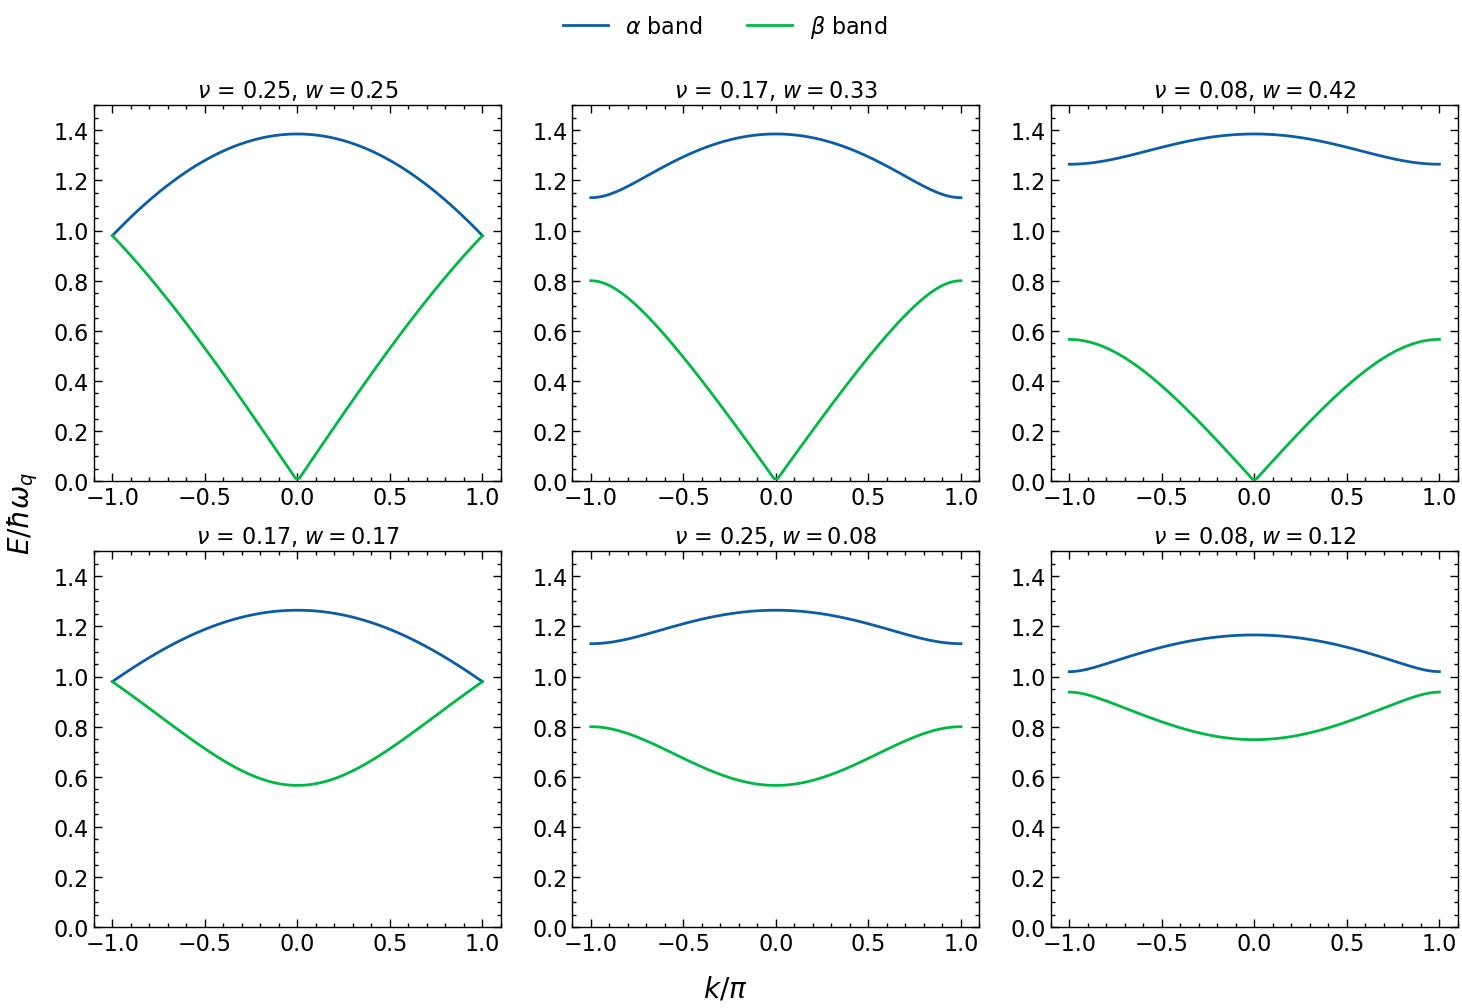

In [2]:
# En el plot los hoppings nu, w estan medidos en unidades de omega_q + 2U
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
k_values = np.linspace(-np.pi, np.pi, 100)

# parametros
omega_q = 10.0
U = 1.0
nu_w_values = [(3.0, 3.0), (2.0, 4.0), (1.0, 5.0), (2.0, 2.0), (3.0, 1.0), (1.0, 1.5)]

top = 1.5
bottom = 0.0

for (nu, w), ax in zip(nu_w_values, axes.flatten()):
    ax.plot(k_values/np.pi, ssh_energies(0, omega_q, nu, w, U, k_values)/omega_q, label= r'$\alpha$ band')
    ax.plot(k_values/np.pi, ssh_energies(1, omega_q, nu, w, U, k_values)/omega_q, label=r'$\beta$ band')
    ax.set_title(rf'$\nu$ = {nu/(omega_q + 2 * U):.2f}, $ w = {w/(omega_q + 2 * U):.2f}$')
    ax.set_ylim(bottom, top)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.02))

fig.supxlabel(r'$k/\pi$', fontsize = 20)
fig.supylabel(r'$E / \hbar\omega_q$', fontsize = 20)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Observaciones de las bandas de la cadena SSH
El modelo cuenta con dos bandas $\alpha, \beta$ las cuales tienen un gap salvo cuando $\nu = w$. Cuando $\nu, w \ll \frac{\hbar \omega_q + 2U}{2}= \frac{1}{2} \sqrt{8E_cE_J}$, las bandas son chatas y son simétricas respecto a $\omega_q$. Conforme aumentan las magnitudes de los hoppings, las bandas se van haciendo cada vez más asimétricas. En particular, cuando $\nu + w = \frac{\hbar \omega_q + 2U}{2}$, se observa que la relación de dispersión es similar a la de los fonones en una cadena 1D con una base de dos sitios: hay una rama acústica con dispersión lineal alrededor de $k = 0$ y hay una rama óptica de mayor energía mucho más chata. Analíticamente se obtiene que en la rama inferior, para $k \ll 1$

$$
E_- \approx \sqrt{(\hbar \omega_q)^2 - 4 U^2}\frac{\eta}{\sqrt{2}} \lvert \sin \frac{k}{2} \rvert, \quad \eta = \frac{4 \nu w}{\left(\frac{\hbar \omega_q + 2U }{2}\right)^2}
$$
Siendo $\eta = 1$ el valor máximo que puede alcanzar fijando $\nu + w = \frac{\hbar \omega_q + 2U}{2}$ que se logra cuando $\nu = w$.

# Comparación resultado analítico - exacto - aproximación cuadrática

In [3]:
def compute_position_exponential(N, u): 
  matrix = np.zeros(shape=(N, N), dtype=complex)
  for m in range(N):
    for n in range(N):
      if m >= n:
        matrix[m][n] = (
          np.exp(-u**2/2)
          * np.exp(0.5 * (gammaln(n+1) - gammaln(m+1)))
          * (1.0j*u)**(m-n)
          * genlaguerre(n, m-n)(u**2)
        )
      else:
        matrix[m][n] = (
          np.exp(-u**2/2)
          * np.exp(0.5 * (gammaln(m+1) - gammaln(n+1)))
          * (1.0j*u)**(n-m)
          * genlaguerre(m, n-m)(u**2)
        )

  return qt.Qobj(matrix)

# hamiltoniano exacto con dimensión truncada en N estados de Fock
def exact_transmon_hamiltonian(N, E_c, E_j):
    charge_number = 0.5j * (E_j/(2*E_c))**0.25 * (qt.destroy(N).dag() - qt.destroy(N))
    phase_prefactor = (2 * E_c / E_j)**0.25
    cos_delta = 0.5 * (compute_position_exponential(N, phase_prefactor) + compute_position_exponential(N, -phase_prefactor))
    return 4 * E_c * charge_number**2 - E_j * cos_delta
# hamiltoniano para una cadena (anillo) de transmon
def exact_transmon_ssh(N, n, E_c, E_J, E_g1, E_g2):
    op_list = [qt.qeye(N) for _ in range(n)]
    full_hamiltonian = qt.qzero_like(qt.tensor(op_list))
    H_j = exact_transmon_hamiltonian(N, E_c, E_J)
    
    # suma de hamiltonianos actuando sobre cada uno de los transmon por separado
    for j in range(n):
        op_list[j] = H_j
        full_hamiltonian += qt.tensor(op_list)
        op_list[j] = qt.qeye(N)

    hbar_g1 = (E_J * E_c**3)**0.5 / (np.sqrt(2) * E_g1)
    hbar_g2 = (E_J * E_c**3)**0.5 / (np.sqrt(2) * E_g2)
    # sumamos términos de acoplamiento
    a = qt.destroy(N)
    charge_op = (a.dag() - a)

    for j in range(n):
        op_list[j] = charge_op
        op_list[(j+1) % n] = charge_op
        if j%2 == 0:
            full_hamiltonian -= hbar_g1 * qt.tensor(op_list)
        else:
            full_hamiltonian -= hbar_g2 * qt.tensor(op_list)

        op_list[j] = qt.qeye(N)
        op_list[(j+1) % n] = qt.qeye(N)
    
    return full_hamiltonian
  
def quadratic_transmon_ssh(N, n, E_c, E_J, E_g1, E_g2):
    op_list = [qt.qeye(N) for _ in range(n)]
    full_hamiltonian = qt.qzero_like(qt.tensor(op_list))
    H_j = np.sqrt(8 * E_c * E_J) * qt.num(N) - (E_c / 12.0) * (12 * qt.num(N) + 6 * (qt.destroy(N)**2 + qt.destroy(N).dag()**2))
    
    # suma de hamiltonianos actuando sobre cada uno de los transmon por separado
    for j in range(n):
        op_list[j] = H_j
        full_hamiltonian += qt.tensor(op_list)
        op_list[j] = qt.qeye(N)

    hbar_g1 = (E_J * E_c**3)**0.5 / (np.sqrt(2) * E_g1)
    hbar_g2 = (E_J * E_c**3)**0.5 / (np.sqrt(2) * E_g2)
    # sumamos términos de acoplamiento
    a = qt.destroy(N)
    charge_op = (a.dag() - a)

    for j in range(n):
        op_list[j] = charge_op
        op_list[(j+1) % n] = charge_op
        if j%2 == 0:
            full_hamiltonian -= hbar_g1 * qt.tensor(op_list)
        else:
            full_hamiltonian -= hbar_g2 * qt.tensor(op_list)

        op_list[j] = qt.qeye(N)
        op_list[(j+1) % n] = qt.qeye(N)
    
    return full_hamiltonian
  
def quadratic_interacting_transmon_ssh(N, n, E_c, E_J, E_g1, E_g2):
    op_list = [qt.qeye(N) for _ in range(n)]
    full_hamiltonian = qt.qzero_like(qt.tensor(op_list))
    H_j = np.sqrt(8 * E_c * E_J) * qt.num(N) - (E_c / 12.0) * (12 * qt.num(N) + 6 * (qt.destroy(N)**2 + qt.destroy(N).dag()**2) + 6 * qt.destroy(N).dag()**2 * qt.destroy(N)**2)
    
    # suma de hamiltonianos actuando sobre cada uno de los transmon por separado
    for j in range(n):
        op_list[j] = H_j
        full_hamiltonian += qt.tensor(op_list)
        op_list[j] = qt.qeye(N)

    hbar_g1 = (E_J * E_c**3)**0.5 / (np.sqrt(2) * E_g1)
    hbar_g2 = (E_J * E_c**3)**0.5 / (np.sqrt(2) * E_g2)
    # sumamos términos de acoplamiento
    a = qt.destroy(N)
    charge_op = (a.dag() - a)

    for j in range(n):
        op_list[j] = charge_op
        op_list[(j+1) % n] = charge_op
        if j%2 == 0:
            full_hamiltonian -= hbar_g1 * qt.tensor(op_list)
        else:
            full_hamiltonian -= hbar_g2 * qt.tensor(op_list)

        op_list[j] = qt.qeye(N)
        op_list[(j+1) % n] = qt.qeye(N)
    
    return full_hamiltonian

### Comparación en nivel del truncamiento para distintos pares de hopping
Vemos si la asimetría de hopping hace necesario introducir una mayor dimensión en el espacio de Fock. Nos fijaremos en el espectro que a lo sumo tiene $m$ cuantos. Es posible demostrar que si hay $n$ transmons, entonces esto corresponde a observar los $M$ primeros niveles de energía, con:
$$
M = {{n+m}\choose{m}}
$$
por tanto para un sistema de $4$ transmons, el espectro de a lo sumo tres excitaciones corresponde con los primeros $35$ niveles de energía.

In [18]:
N_values = [5, 8, 10]
n = 4
E_c = 1.0
E_j = 50.0
omega_q = np.sqrt(8 * E_c * E_j) - E_c
U = E_c / 2
M = 35
nu_w_pairs = [(0.40, 0.60), (0.1, 0.9), (0.7, 0.3), (0.5, 0.2), (0.3, 0.4), (0.8, 0.1)]
E_g_values = 0.5 * (omega_q + 2 * U) * np.array(nu_w_pairs)

energy_matrix = []
for N in N_values:
    energies = []
    for E_g in E_g_values:
        hamiltonian = exact_transmon_ssh(N, n, E_c, E_j, *E_g)
        energies.append(np.sort(hamiltonian.eigenenergies(sparse = True, sort = 'low', eigvals = M))) # solo calculamos los primeros M autovalores
    energy_matrix.append(np.array(energies))

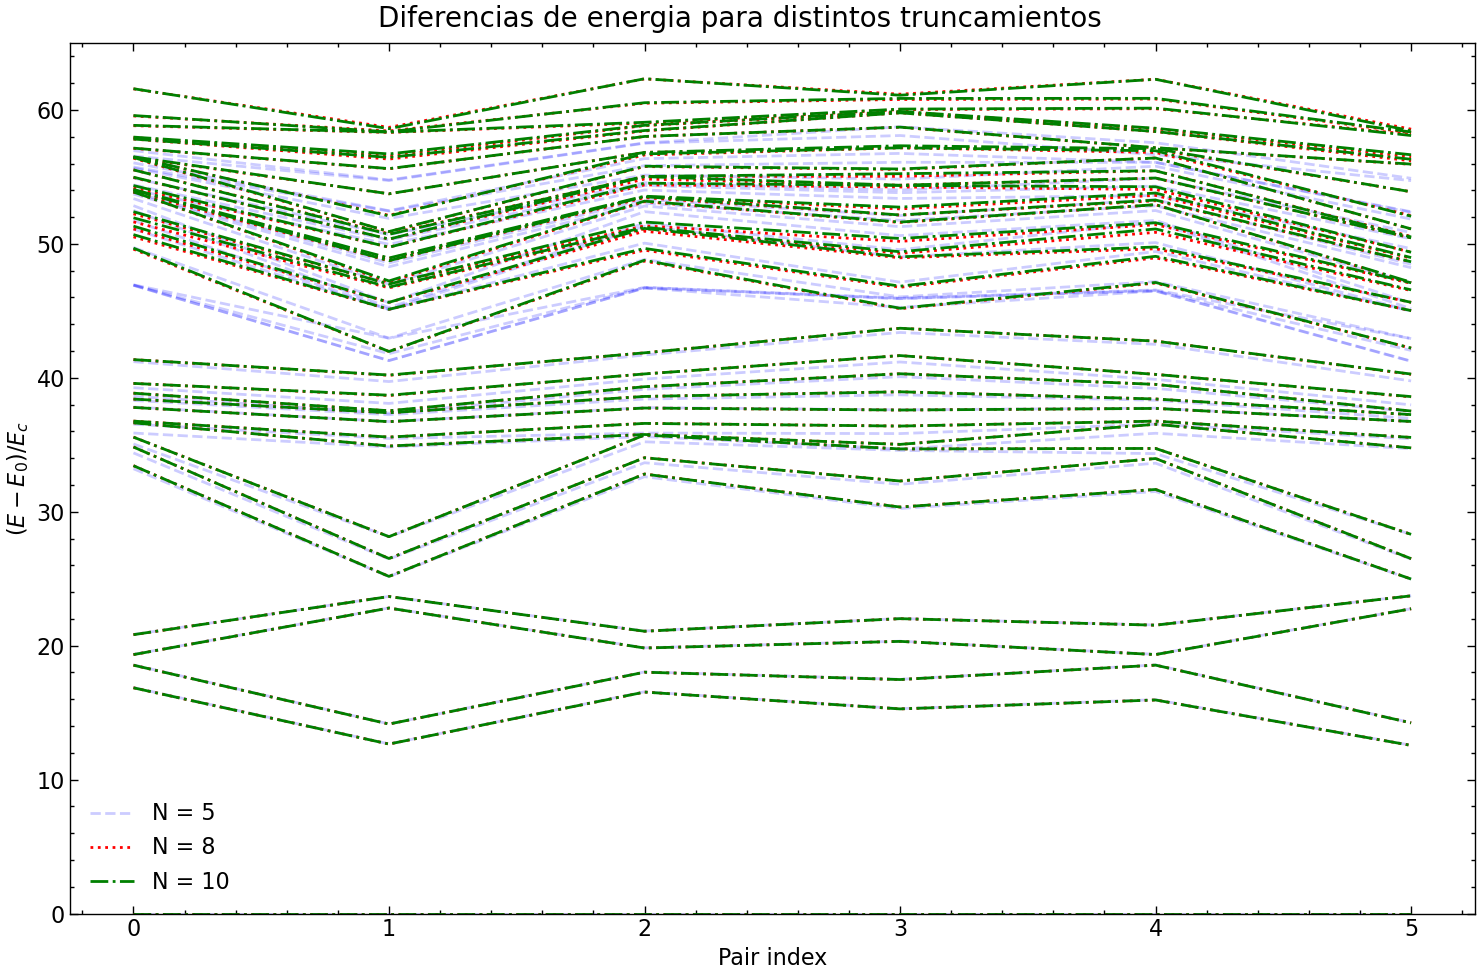

In [ ]:
fig, ax = plt.subplots(figsize=(15, 10))
fig.suptitle('Diferencias de energia para distintos truncamientos', fontsize=20)
styles = ['b--', 'r:', 'g-.', 'k--']
ax.set_xlabel('Pair index')
ax.set_ylabel('$(E - E_0)/E_c$')

pair_indices = np.arange(len(E_g_values))  # [0, 1, 2, 3, 4, 5]

for energy_array, style, N in zip(energy_matrix, styles, N_values):
    ground = energy_array.T[0]
    if N == 5:
        alpha = 0.2
    else:
        alpha = 1.0
    for level_idx, level in enumerate(energy_array.T):
        if level_idx == 0:
            ax.plot(pair_indices, np.zeros_like(level), style, label=f"N = {N}", alpha = alpha)
        else:
            ax.plot(pair_indices, level - ground, style, alpha = alpha)

ax.set_xticks(pair_indices)  # optional: force integer ticks
ax.set_ylim(0.0, 65.0)
plt.legend()
fig.tight_layout()
plt.show()

Para los parámetros utilizados (que abarcan valores en los cuales se satisface la condición para $\nu + w = \frac{\hbar \omega_q + 2U}{2}$), el espectro de energías para 3 o menos excitaciones está muy bien descrito para $N = 8$ y la diferencia no es suficientemente apreciable cuando pasamos a $N = 10$.

# Comparación en función de la aproximación utilizada

In [ ]:
N = 8
n = 4
E_c = 1.0
E_j = 50.0
omega_q = np.sqrt(8 * E_c * E_j) - E_c
U = E_c / 2
M = 35
nu_w_pairs = [(0.40, 0.60), (0.1, 0.9), (0.7, 0.3), (0.5, 0.2), (0.3, 0.4), (0.8, 0.1)]
E_g_values = 0.5 * (omega_q + 2 * U) * np.array(nu_w_pairs)


hamiltonians = [exact_transmon_ssh, quadratic_transmon_ssh, quadratic_interacting_transmon_ssh]
energy_matrix = []

for hamiltonian_function in hamiltonians:
    energies = []
    for E_g in E_g_values:
        hamiltonian = hamiltonian_function(N, n, E_c, E_j, *E_g)
        energies.append(np.array(hamiltonian.eigenenergies(sparse = True, sort = 'low', eigvals = M)))

    energy_matrix.append(np.array(energies))
    
energy_matrix = np.array(energy_matrix)

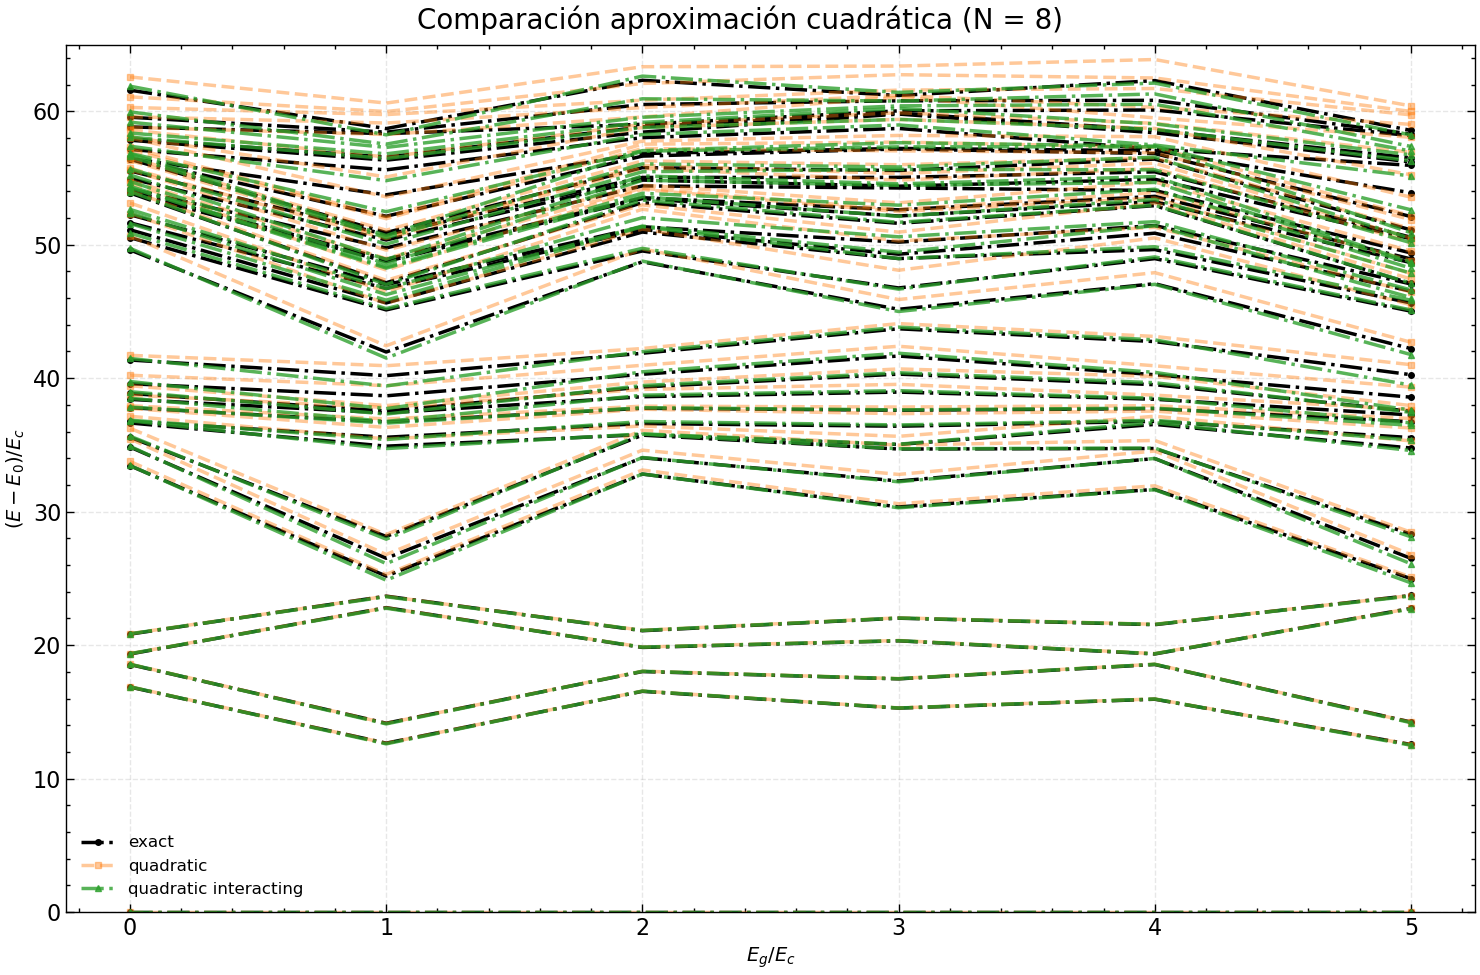

In [37]:
fig, ax = plt.subplots(figsize=(15, 10))

fig.suptitle('Comparación aproximación cuadrática (N = 8)', fontsize=20)

# More distinct styles with different colors, line styles, and markers
styles = [
    {'color': "#000000", 'linestyle': '-.', 'linewidth': 2.5, 'marker': 'o', 'markersize': 4, 'markevery': 5},
    {'color': "#ff7e0e6c", 'linestyle': '--', 'linewidth': 2.5, 'marker': 's', 'markersize': 4, 'markevery': 5},
    {'color': "#2ca02cca", 'linestyle': '-.', 'linewidth': 2.5, 'marker': '^', 'markersize': 4, 'markevery': 5}
]
labels = ['exact', 'quadratic', 'quadratic interacting']

ax.set_xlabel('$E_g/E_c$', fontsize=14)
ax.set_ylabel('$(E- E_0)/E_c$', fontsize=14)

for energy_array, style, labl in zip(energy_matrix, styles, labels):
    ground = energy_array.T[0]
    for level_idx, level in enumerate(energy_array.T):
        if level_idx == 0:
            ax.plot(pair_indices, np.zeros_like(level), 
                   label=labl, **style)
        else:
            ax.plot(pair_indices, level - ground, **style)

y_min = 0.0
y_max = 65.0
ax.set_ylim(y_min, y_max)
ax.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=12, framealpha=0.9)
fig.tight_layout()
plt.show()

También se concluye que alcanza con el término cuadrático más la interacción para describir correctamente los niveles

# Comparación con la teoría de perturbaciones sobre el término de interacción

In [4]:
def first_order_interaction_ssh(E_j, E_c, E_g_nu, E_g_w, n, fock_alpha, fock_beta):
    """
    First-order Kerr effective Hamiltonian for the SSH polariton chain.

    The SSH chain has two sublattice sites (A, B) per unit cell with TWO
    distinct hoppings:
        nu  (intracell:  A -> B within the same cell)
        w   (intercell:  B -> A between neighbouring cells)

    This gives two Bogoliubov branches (alpha = bonding, beta = antibonding).
    The SSH coupling at momentum k is:

        |Δk| = sqrt(nu^2 + w^2 + 2*nu*w*cos(k))

    Due to the sublattice parity selection rule (A and B enter the beta branch
    with opposite signs), the quartic Kerr interaction decomposes as:

        Σ_σ b†_{pσ}b†_{qσ}b_{rσ}b_{sσ} = 2(αααα) + 2(ααββ) + 2(ββββ)

    Applying the simple-chain formula sector by sector and collecting:

        H_eff = (2U / N_sites) * [
            - B_total^2
            + (1/2) * C_total^2
            + B_total
            - (3/8) * Σ_k [ sinh^2(2θ+_k) + sinh^2(2θ-_k) ]
        ]

    where:
        B_total = P_alpha + P_beta + S_alpha + S_beta
        C_total = Σ_k [ sinh(2θ+_k)(n̂_α(k)+1/2) + sinh(2θ-_k)(n̂_β(k)+1/2) ]

        P_alpha = Σ_k cosh(2θ+_k) n̂_α(k)
        P_beta  = Σ_k cosh(2θ-_k) n̂_β(k)
        S_alpha = Σ_k sinh²(θ+_k)    (vacuum squeezing, c-number)
        S_beta  = Σ_k sinh²(θ-_k)    (vacuum squeezing, c-number)

    The -N_sites/2 of the chain formula is absorbed:
        sum cosh(2θ)/2 - 1/2 = sinh²θ  =>  S already contains it.

    Simple-chain limit: set E_g_nu = E_g_w (=> nu = w = g).
    With BZ unfolding (alpha at k <-> chain at q=k/2, beta at k <-> chain at
    q=π-k/2) the formula collapses exactly to first_order_interaction().

    Parameters
    ----------
    E_j : float
        Josephson energy.
    E_c : float
        Charging energy (on-site frequency and Kerr).
    E_g_nu : float
        Coupling energy for the intracell hopping nu.
        nu = sqrt(E_j * E_c^3) / (sqrt(2) * E_g_nu)
    E_g_w : float
        Coupling energy for the intercell hopping w.
        w  = sqrt(E_j * E_c^3) / (sqrt(2) * E_g_w)
        Set E_g_w = E_g_nu to recover the simple-chain limit (nu = w).
    n : int
        Number of unit cells. Total sites N_sites = 2n.
        SSH BZ: k in [-pi, pi), n momenta.
    fock_alpha : array-like, length n
        Bogoliubov occupation numbers for the alpha (bonding) branch.
    fock_beta : array-like, length n
        Bogoliubov occupation numbers for the beta (antibonding) branch.

    Returns
    -------
    float
        First-order Kerr energy for the given Fock state.

    Notes
    -----
    Physical parameters:
        omega_q = sqrt(8 E_c E_j) - E_c
        nu      = sqrt(E_j E_c^3) / (sqrt(2) E_g_nu)   intracell hopping
        w       = sqrt(E_j E_c^3) / (sqrt(2) E_g_w)    intercell hopping
        U       = E_c / 2   (= 6*lambda,  lambda = E_c/12)

    SSH coupling:
        |Δk| = sqrt(nu^2 + w^2 + 2*nu*w*cos(k))

    BdG eigenvalues:
        E+_k = sqrt((omega_q - 2U)(omega_q + 2U + 2|Δk|))   bonding
        E-_k = sqrt((omega_q - 2U)(omega_q + 2U - 2|Δk|))   antibonding

    Bogoliubov angles:
        cosh(2θ±_k) = (omega_q ± |Δk|) / E±_k
        sinh(2θ±_k) = (2U     ± |Δk|) / E±_k
        sinh²(θ±_k) = (omega_q ± |Δk| - E±_k) / (2 E±_k)
    """
    fock_alpha = np.asarray(fock_alpha, dtype=float)
    fock_beta  = np.asarray(fock_beta,  dtype=float)
    assert len(fock_alpha) == n and len(fock_beta) == n, \
        "fock_alpha and fock_beta must each have length n (number of unit cells)"

    # ------------------------------------------------------------------ #
    # Physical parameters
    # ------------------------------------------------------------------ #
    omega_q = np.sqrt(8.0 * E_c * E_j) - E_c
    g_scale = np.sqrt(E_j * E_c**3) / np.sqrt(2.0)
    nu      = g_scale / E_g_nu          # intracell hopping
    w       = g_scale / E_g_w           # intercell hopping
    U       = E_c / 2.0                 # Kerr coefficient
    N_sites = 2 * n

    # ------------------------------------------------------------------ #
    # SSH momenta and coupling  |Δk| = |nu + w*e^{ik}|
    # ------------------------------------------------------------------ #
    k  = np.linspace(-np.pi, np.pi, n, endpoint=False)
    Dk = np.sqrt(nu**2 + w**2 + 2.0 * nu * w * np.cos(k))   # |Δk|, shape (n,)

    # ------------------------------------------------------------------ #
    # BdG eigenvalues
    # ------------------------------------------------------------------ #
    E_plus  = np.sqrt((omega_q - 2*U) * (omega_q + 2*U + 2*Dk))
    E_minus = np.sqrt((omega_q - 2*U) * (omega_q + 2*U - 2*Dk))

    if np.any(omega_q + 2*U - 2*Dk < 0):
        import warnings
        warnings.warn(
            "Antibonding branch has imaginary frequencies (omega_q + 2U < 2|Δk|). "
            "The perturbative expansion may be unreliable.",
            RuntimeWarning
        )

    # ------------------------------------------------------------------ #
    # Bogoliubov coherence factors
    # ------------------------------------------------------------------ #
    cosh2_plus  = (omega_q + Dk) / E_plus       # cosh(2θ+)
    cosh2_minus = (omega_q - Dk) / E_minus      # cosh(2θ-)

    sinh2_plus  = (2*U + Dk) / E_plus           # sinh(2θ+)
    sinh2_minus = (2*U - Dk) / E_minus          # sinh(2θ-)

    sinh2th_plus  = (omega_q + Dk - E_plus)  / (2.0 * E_plus)   # sinh²θ+
    sinh2th_minus = (omega_q - Dk - E_minus) / (2.0 * E_minus)  # sinh²θ-

    # ------------------------------------------------------------------ #
    # Vacuum sums  S = Σ_k sinh²θ  (c-numbers)
    # ------------------------------------------------------------------ #
    S_alpha = np.sum(sinh2th_plus)
    S_beta  = np.sum(sinh2th_minus)

    # ------------------------------------------------------------------ #
    # B_total = P_alpha + P_beta + S_alpha + S_beta
    # (the -N_sites/2 is absorbed: sum cosh(2θ)/2 - 1/2 = sinh²θ = S)
    # ------------------------------------------------------------------ #
    P_alpha = np.sum(cosh2_plus  * fock_alpha)
    P_beta  = np.sum(cosh2_minus * fock_beta)
    B_total = P_alpha + P_beta + S_alpha + S_beta

    # ------------------------------------------------------------------ #
    # C_total = Σ_k [ sinh(2θ+)(n_α+1/2) + sinh(2θ-)(n_β+1/2) ]
    # ------------------------------------------------------------------ #
    C_total = (np.sum(sinh2_plus  * (fock_alpha + 0.5))
             + np.sum(sinh2_minus * (fock_beta  + 0.5)))

    # ------------------------------------------------------------------ #
    # Constant D = (3/8) Σ_k [ sinh²(2θ+) + sinh²(2θ-) ]
    # ------------------------------------------------------------------ #
    D = (3.0 / 8.0) * (np.sum(sinh2_plus**2) + np.sum(sinh2_minus**2))

    # ------------------------------------------------------------------ #
    # H_eff = (2U / N_sites) * [ -B^2 + (1/2)C^2 + B - D ]
    # ------------------------------------------------------------------ #
    return (2.0 * U / N_sites) * (
        - B_total**2
        + 0.5 * C_total**2
        + B_total
        - D
    )


def first_order_interaction(E_j, E_c, E_g, n, fock_state):
    """
    Original simple-chain formula (reference, unchanged).

    Parameters
    ----------
    E_j, E_c, E_g : float
        Physical parameters.
    n : int
        Number of sites.
    fock_state : array-like, length n
        Bogoliubov occupation numbers.

    Returns
    -------
    float
        First-order Kerr energy.
    """
    omega_q   = np.sqrt(8 * E_c * E_j) - E_c
    g         = (E_j * E_c**3)**0.5 / (np.sqrt(2) * E_g)
    k_values  = np.linspace(-np.pi, np.pi, n, endpoint=False)
    lamb      = E_c / 12.0
    U         = 6 * lamb
    epsilon_k = lambda k: omega_q + 2 * g * np.cos(k)
    delta_k   = lambda k: 2 * g * np.cos(k) + 12 * lamb

    A, B, C = 0.0, -n / 2.0, 0.0
    for k, occupation in zip(k_values, fock_state):
        Ek = np.sqrt(epsilon_k(k)**2 - delta_k(k)**2)
        A += delta_k(k)   * (occupation + 0.5) / Ek
        B += epsilon_k(k) * (occupation + 0.5) / Ek
        C += (3.0 / 8.0)  * delta_k(k)**2 / (epsilon_k(k)**2 - delta_k(k)**2)

    return 2 * U * (0.5 * A**2 - B**2 + B - C) / n


# --------------------------------------------------------------------------- #
# Comprobamos si en el limite de hoppings iguales las funciones dan lo mismo y si realmente difieren cuando no
# --------------------------------------------------------------------------- #
if __name__ == "__main__":

    E_j, E_c, E_g = 20.0, 0.3, 5.0
    n_cells = 20
    rng = np.random.default_rng(42)

    # BZ unfolding map: alpha[i] -> chain q=k[i]/2, beta[i] -> chain q=π-k[i]/2
    def ssh_to_chain_fock(fa, fb, n):
        kc = np.linspace(-np.pi, np.pi, 2*n, endpoint=False)
        ks = np.linspace(-np.pi, np.pi, n,   endpoint=False)
        fc = np.zeros(2*n)
        for i in range(n):
            ia = np.argmin(np.abs(kc - ks[i] / 2.0))
            qb = ((np.pi - ks[i] / 2.0 + np.pi) % (2*np.pi)) - np.pi
            ib = np.argmin(np.abs(kc - qb))
            fc[ia] += fa[i]
            fc[ib] += fb[i]
        return fc

    # ------------------------------------------------------------------ #
    print("Test 1: simple-chain limit  (nu = w = g,  E_g_nu = E_g_w)")
    print(f"{'State':<24} {'SSH H_eff':>14} {'Chain H_eff':>14} {'Match':>6}")
    print("-" * 62)

    cases = [
        ("vacuum",        np.zeros(n_cells), np.zeros(n_cells)),
        ("1 alpha k[0]",  np.eye(n_cells)[0], np.zeros(n_cells)),
        ("1 beta  k[5]",  np.zeros(n_cells),  np.eye(n_cells)[5]),
        ("2 alpha k[3]",  2*np.eye(n_cells)[3], np.zeros(n_cells)),
        ("alpha+beta",    np.eye(n_cells)[2],  np.eye(n_cells)[7]),
        ("random",        rng.integers(0,3,n_cells).astype(float),
                          rng.integers(0,3,n_cells).astype(float)),
    ]

    all_pass = True
    for label, fa, fb in cases:
        E_ssh   = first_order_interaction_ssh(E_j, E_c, E_g, E_g, n_cells, fa, fb)
        fc      = ssh_to_chain_fock(fa, fb, n_cells)
        E_chain = first_order_interaction(E_j, E_c, E_g, 2*n_cells, fc)
        ok      = np.isclose(E_ssh, E_chain, rtol=1e-6)
        all_pass &= ok
        print(f"{label:<24} {E_ssh:>14.6f} {E_chain:>14.6f} {'✓' if ok else '✗':>6}")

    print(f"All chain-limit tests passed: {all_pass}\n")

    # ------------------------------------------------------------------ #
    print("Test 2: genuine SSH (nu != w)  —  alpha vs beta asymmetry")
    print(f"{'State':<30} {'H_eff':>12}")
    print("-" * 46)

    E_g_nu, E_g_w = 4.0, 7.0    # nu != w => true SSH dimerization
    fa1 = np.zeros(n_cells); fa1[n_cells//2] = 1
    fb1 = np.zeros(n_cells); fb1[n_cells//2] = 1
    fv  = np.zeros(n_cells)

    Ev  = first_order_interaction_ssh(E_j, E_c, E_g_nu, E_g_w, n_cells, fv,  fv)
    Ea  = first_order_interaction_ssh(E_j, E_c, E_g_nu, E_g_w, n_cells, fa1, fv)
    Eb  = first_order_interaction_ssh(E_j, E_c, E_g_nu, E_g_w, n_cells, fv,  fb1)
    Eab = first_order_interaction_ssh(E_j, E_c, E_g_nu, E_g_w, n_cells, fa1, fb1)

    for label, val in [
        ("vacuum",               Ev),
        ("1 alpha qp (k=k[n/2])", Ea),
        ("1 beta  qp (k=k[n/2])", Eb),
        ("1 alpha + 1 beta",      Eab),
    ]:
        print(f"{label:<30} {val:>12.6f}")

    print()
    print(f"alpha Kerr shift: {Ea-Ev:+.6f}")
    print(f"beta  Kerr shift: {Eb-Ev:+.6f}")
    print("(These differ because nu != w breaks alpha <-> beta symmetry)")

Test 1: simple-chain limit  (nu = w = g,  E_g_nu = E_g_w)
State                         SSH H_eff    Chain H_eff  Match
--------------------------------------------------------------
vacuum                         0.002922       0.002922      ✓
1 alpha k[0]                   0.002858       0.002858      ✓
1 beta  k[5]                   0.002712       0.002712      ✓
2 alpha k[3]                  -0.012053      -0.012053      ✓
alpha+beta                    -0.012348      -0.012348      ✓
random                       -14.872456     -14.872456      ✓
All chain-limit tests passed: True

Test 2: genuine SSH (nu != w)  —  alpha vs beta asymmetry
State                                 H_eff
----------------------------------------------
vacuum                             0.002920
1 alpha qp (k=k[n/2])              0.003045
1 beta  qp (k=k[n/2])              0.002648
1 alpha + 1 beta                  -0.012261

alpha Kerr shift: +0.000125
beta  Kerr shift: -0.000271
(These differ because nu !=

Cuando $\hbar(\nu + w) = \sqrt{8E_c E_j}$, la corrección dada por la perturbación tiene un comportamiento patológico en la rama inferior cuando $k = 0$, llegando a diverger negativamente cuando la condición se cumple exactamente. El efecto de la perturbación es más apreciable conforme nos acercamos a este límite.

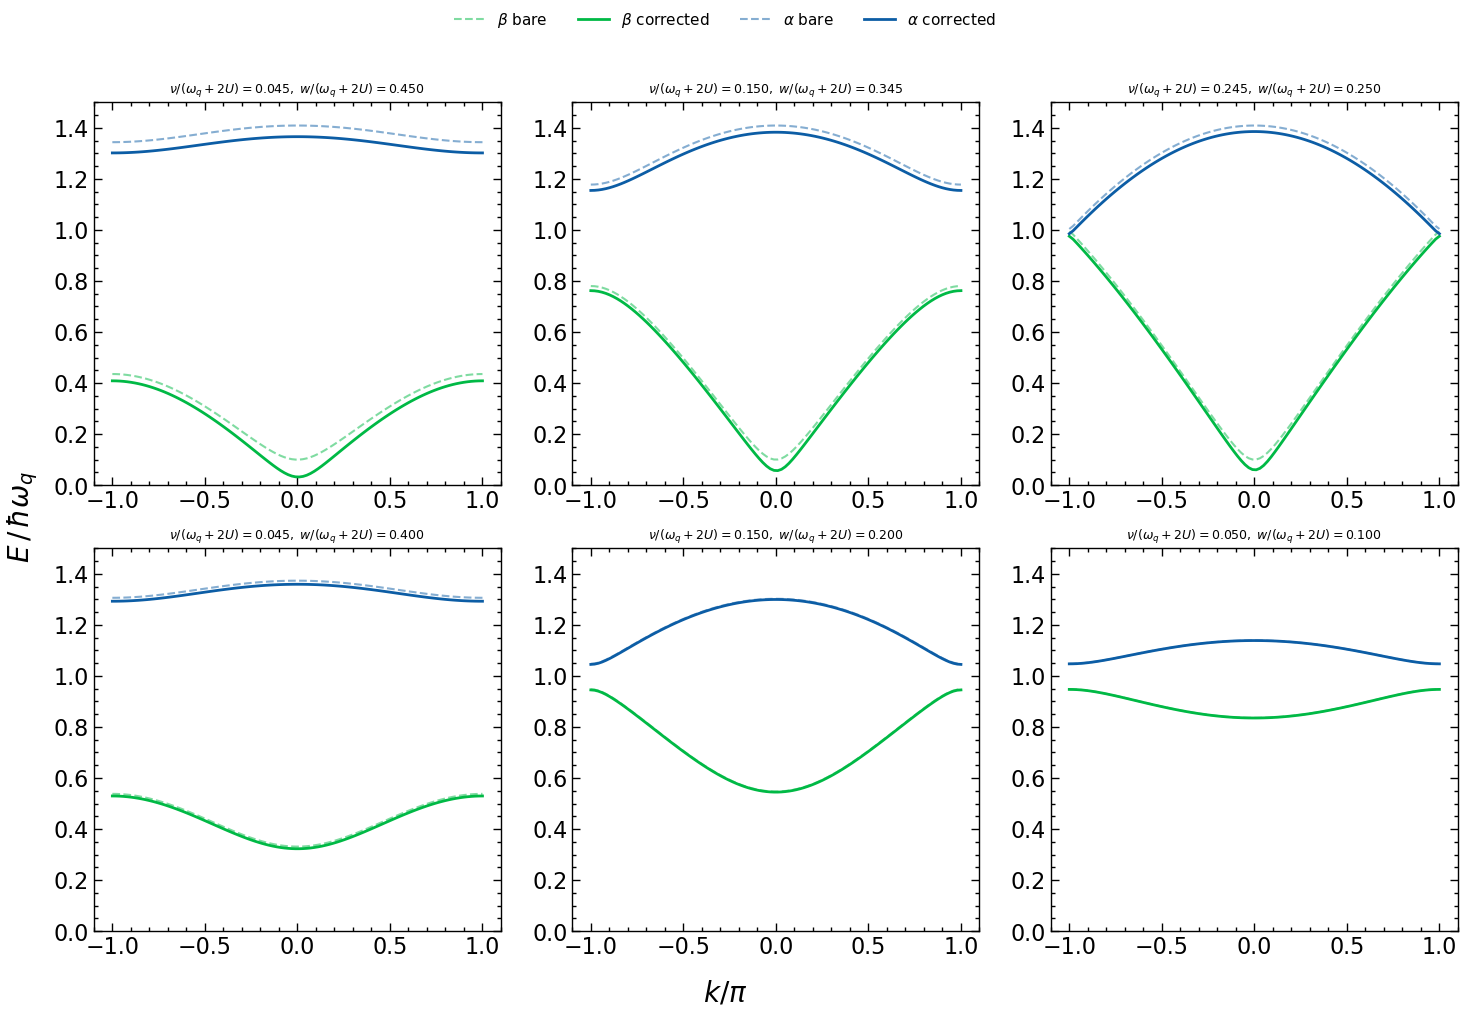

In [37]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable


# ------------------------------------------------------------------ #
# Physical parameters
# ------------------------------------------------------------------ #
E_j       = 50.0
E_c       = 1.0
prefactor = np.sqrt(E_j * E_c**3) / np.sqrt(2.0)
omega_q   = np.sqrt(8 * E_c * E_j) - E_c          # correct formula
U         = E_c / 2.0                              # correct: E_c/2, not 1.0
n         = 100
k_values  = np.linspace(-np.pi, np.pi, n)

# Scale factor for hoppings: keep nu+w < (omega_q+2U)/2 for stability.
# Using 0.05*(omega_q+2U) as the base unit so all six cases are stable.
scale = 0.5 * (omega_q + 2*U)


# ------------------------------------------------------------------ #
# BdG dispersion helper
# ------------------------------------------------------------------ #
def ssh_energies(branch, omega_q, nu, w, U, k):
    Dk = np.sqrt(nu**2 + w**2 + 2*nu*w*np.cos(k))
    if branch == 0:   # alpha (bonding)
        return np.sqrt((omega_q - 2*U) * (omega_q + 2*U + 2*Dk))
    else:             # beta (antibonding)
        return np.sqrt((omega_q - 2*U) * (omega_q + 2*U - 2*Dk))


# ------------------------------------------------------------------ #
# Fixed hoppings: one panel per (nu, w) pair
# ------------------------------------------------------------------ #
nu_w_factors = [(0.09, 0.9), (0.3, 0.69), (0.49, 0.5),
                (0.09, 0.8), (0.3, 0.4), (0.1, 0.2)]

# ------------------------------------------------------------------ #
# Figure: bare beta band + first-order correction
# ------------------------------------------------------------------ #
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))

for (nf, wf), ax in zip(nu_w_factors, axes.flatten()):

    nu    = scale * nf
    w     = scale * wf
    E_g_nu = prefactor / nu
    E_g_w  = prefactor / w

    # --- ground state correction (vacuum, subtract from all) ---
    E_vac = first_order_interaction_ssh(
        E_j, E_c, E_g_nu, E_g_w, n,
        np.zeros(n), np.zeros(n)
    )

    # --- beta correction: one quasiparticle at each k ---
    beta_correction = np.array([
        first_order_interaction_ssh(
            E_j, E_c, E_g_nu, E_g_w, n,
            np.zeros(n), np.eye(n)[j]
        ) for j in range(n)
    ]) - E_vac

    # --- alpha correction for comparison ---
    alpha_correction = np.array([
        first_order_interaction_ssh(
            E_j, E_c, E_g_nu, E_g_w, n,
            np.eye(n)[j], np.zeros(n)
        ) for j in range(n)
    ]) - E_vac

    # --- bare dispersions ---
    E_alpha_bare = ssh_energies(0, omega_q, nu, w, U, k_values)
    E_beta_bare  = ssh_energies(1, omega_q, nu, w, U, k_values)

    # --- plot ---
    ax.plot(k_values / np.pi, E_beta_bare / omega_q,
            color='C1', lw=1.5, ls='--', alpha=0.5, label=r'$\beta$ bare')
    ax.plot(k_values / np.pi, (E_beta_bare + beta_correction) / omega_q,
            color='C1', lw=2.0, label=r'$\beta$ corrected')
    ax.plot(k_values / np.pi, E_alpha_bare / omega_q,
            color='C0', lw=1.5, ls='--', alpha=0.5, label=r'$\alpha$ bare')
    ax.plot(k_values / np.pi, (E_alpha_bare + alpha_correction) / omega_q,
            color='C0', lw=2.0, label=r'$\alpha$ corrected')

    ax.set_title(
        rf'$\nu/(\omega_q+2U)={nf*0.5:.3f},\; w/(\omega_q+2U)={wf*0.5:.3f}$',
        fontsize=9
    )
    ax.set_ylim(0.0, 1.5)

# --- shared legend and labels ---
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4,
           bbox_to_anchor=(0.5, 1.02), fontsize=11)
fig.supxlabel(r'$k/\pi$', fontsize=20)
fig.supylabel(r'$E\,/\,\hbar\omega_q$', fontsize=20)
fig.tight_layout(rect=[0, 0, 1, 0.95])
# plt.savefig('beta_correction_bands.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# Solo comparamos con el hamiltoniano en aproximación cuadrática y con término de interacción

N = 8
n = 4
E_c = 1.0
E_j = 50.0
omega_q = np.sqrt(8 * E_c * E_j) - E_c
U = E_c / 2
M = 35
nu_w_pairs = [(0.40, 0.5), (0.1, 0.8), (0.6, 0.3), (0.5, 0.2), (0.3, 0.4), (0.8, 0.1)]
E_g_values = 0.5 * (omega_q + 2 * U) * np.array(nu_w_pairs)


hamiltonians = [quadratic_interacting_transmon_ssh]
energy_matrix = []

for hamiltonian_function in hamiltonians:
    energies = []
    for E_g in E_g_values:
        hamiltonian = hamiltonian_function(N, n, E_c, E_j, *E_g)
        energies.append(np.array(hamiltonian.eigenenergies(sparse = True, sort = 'low', eigvals = M)))

    energy_matrix.append(np.array(energies))
    
energy_matrix = np.array(energy_matrix)

In [5]:
# Para cada uno de los hoppings, generamos todos los estados de Fock hasta 5 excitaciones y nos quedamos con los primeros M en energía

from itertools import combinations_with_replacement

def generate_ssh_fock_states(n, n_excitations):
    """
    Generate all SSH Fock states with exactly n_excitations quanta
    distributed over 2n modes (n alpha + n beta).

    Returns
    -------
    np.ndarray, shape (N_states, 2, n)
        Axis 1: 0 = alpha branch, 1 = beta branch.
        Axis 2: momentum index.
    """
    fock_states = []
    for combo in combinations_with_replacement(range(2 * n), n_excitations):
        occupation = [0] * (2 * n)
        for idx in combo:
            occupation[idx] += 1
        fock_states.append(occupation)

    return np.array(fock_states).reshape(-1, 2, n)  # -1 instead of counter


def quantum_capped_states(n, M):
    """
    Generate all SSH Fock states with 0, 1, ..., M excitations.

    Returns
    -------
    np.ndarray, shape (N_total, 2, n)
    """
    all_states = []
    for j in range(M + 1):                          # fix: range(M+1) to include M
        states = generate_ssh_fock_states(n, j)
        all_states.append(states)
    return np.concatenate(all_states, axis=0)        # fix: concatenate, not np.append

def fock_state_energies(n, E_c, E_j, nu, w, fock_alpha, fock_beta):
    energy = 0.0
    omega_q = np.sqrt(8 * E_c * E_j) - E_c          # fix: was sqrt(E_c*E_j)
    U = E_c / 2.0
    k_values = np.linspace(-np.pi, np.pi, n, endpoint=False)
    for k, alpha_occupation, beta_occupation in zip(k_values, fock_alpha, fock_beta):
        energy += ssh_energies(0, omega_q, nu, w, U, k) * alpha_occupation
        energy += ssh_energies(1, omega_q, nu, w, U, k) * beta_occupation
    return energy

def generate_lowest_quadratic_energies(n, M, L, E_c, E_j, E_g_nu, E_g_w):
    trial_states = quantum_capped_states(n, M)
    prefactor = np.sqrt(E_j * E_c**3) / np.sqrt(2)
    nu = prefactor / E_g_nu
    w  = prefactor / E_g_w
    ground_state_correction = first_order_interaction_ssh(E_j, E_c, E_g_nu, E_g_w, n, np.zeros(n), np.zeros(n))
    
    trial_energies = np.array([
        fock_state_energies(n, E_c, E_j, nu, w, state[0], state[1])
        for state in trial_states
    ])                                         # fix: numpy array, not list
    idx = np.argsort(trial_energies)
    return trial_energies[idx][:L], trial_states[idx][:L]   # also slice to L

def generate_lowest_perturbed_quadratic_energies(n, M, L, E_c, E_j, E_g_nu, E_g_w):
    trial_states = quantum_capped_states(n, M)
    prefactor = np.sqrt(E_j * E_c**3) / np.sqrt(2)
    nu = prefactor / E_g_nu
    w  = prefactor / E_g_w
    ground_state_correction = first_order_interaction_ssh(E_j, E_c, E_g_nu, E_g_w, n, np.zeros(n), np.zeros(n))
    
    trial_energies = np.array([
        fock_state_energies(n, E_c, E_j, nu, w, state[0], state[1]) + first_order_interaction_ssh(E_j, E_c, E_g_nu, E_g_w, n, state[0], state[1])
        for state in trial_states
    ]) - ground_state_correction                                               # fix: numpy array, not list
    idx = np.argsort(trial_energies)
    return trial_energies[idx][:L], trial_states[idx][:L]   # also slice to L

In [7]:
N = 8
n = 4
E_c = 1.0
E_j = 50.0
omega_q = np.sqrt(8 * E_c * E_j) - E_c
U = E_c / 2
M = 35

nu_w_pairs = [(0.40, 0.5), (0.1, 0.8), (0.6, 0.3), (0.5, 0.2), (0.3, 0.4), (0.8, 0.1)]
E_g_values = 0.5 * (omega_q + 2 * U) * np.array(nu_w_pairs)
pair_indices = np.arange(len(nu_w_pairs))           # was missing in original

# ------------------------------------------------------------------ #
# Exact and quadratic Hamiltonians
# ------------------------------------------------------------------ #
hamiltonians = [exact_transmon_ssh, quadratic_transmon_ssh, quadratic_interacting_transmon_ssh]
energy_matrix = []

for hamiltonian_function in hamiltonians:
    energies = []
    for E_g in E_g_values:
        hamiltonian = hamiltonian_function(N, n, E_c, E_j, *E_g)
        energies.append(np.array(
            hamiltonian.eigenenergies(sparse=True, sort='low', eigvals=M)
        ))
    energy_matrix.append(np.array(energies))

energy_matrix = np.array(energy_matrix)   # shape: (3, n_pairs, M)

# ------------------------------------------------------------------ #
# Analytical (perturbative) energies
# M_trial controls how many excitations to consider when generating
# the trial Fock space; increase if lowest M levels are not converged
# ------------------------------------------------------------------ #
M_trial = 6   # generate states with 0..M_trial excitations

analytical_energies = []
for E_g_nu, E_g_w in E_g_values:
    energies_pair, _ = generate_lowest_quadratic_energies(
        n, M_trial, M, E_c, E_j, E_g_nu, E_g_w
    )
    analytical_energies.append(energies_pair)

analytical_energies = np.array(analytical_energies)  # shape: (n_pairs, M)

# Stack with the other methods: energy_matrix becomes shape (4, n_pairs, M)
energy_matrix = np.concatenate(
    [energy_matrix, analytical_energies[np.newaxis, :, :]],
    axis=0
)
#------------------------------------------------------------------ #
# Recalculate analytical energies with more quanta, reuse energy_matrix[:3]
#------------------------------------------------------------------ #
M_trial = 10
M_new = 150

analytical_energies = []
for E_g_nu, E_g_w in E_g_values:
    energies_pair, _ = generate_lowest_quadratic_energies(
        n, M_trial, M_new, E_c, E_j, E_g_nu, E_g_w
    )
    analytical_energies.append(energies_pair)

analytical_energies = np.array(analytical_energies)  # shape: (n_pairs, M_new)

# Pad the 3 numerical results from M=35 to M=70 with NaN
M_old = energy_matrix[:3].shape[2]   # = 35
pad = np.full((3, len(nu_w_pairs), M_new - M_old), np.nan)
energy_matrix_padded = np.concatenate([energy_matrix[:3], pad], axis=2)

# Now concatenate the analytical row


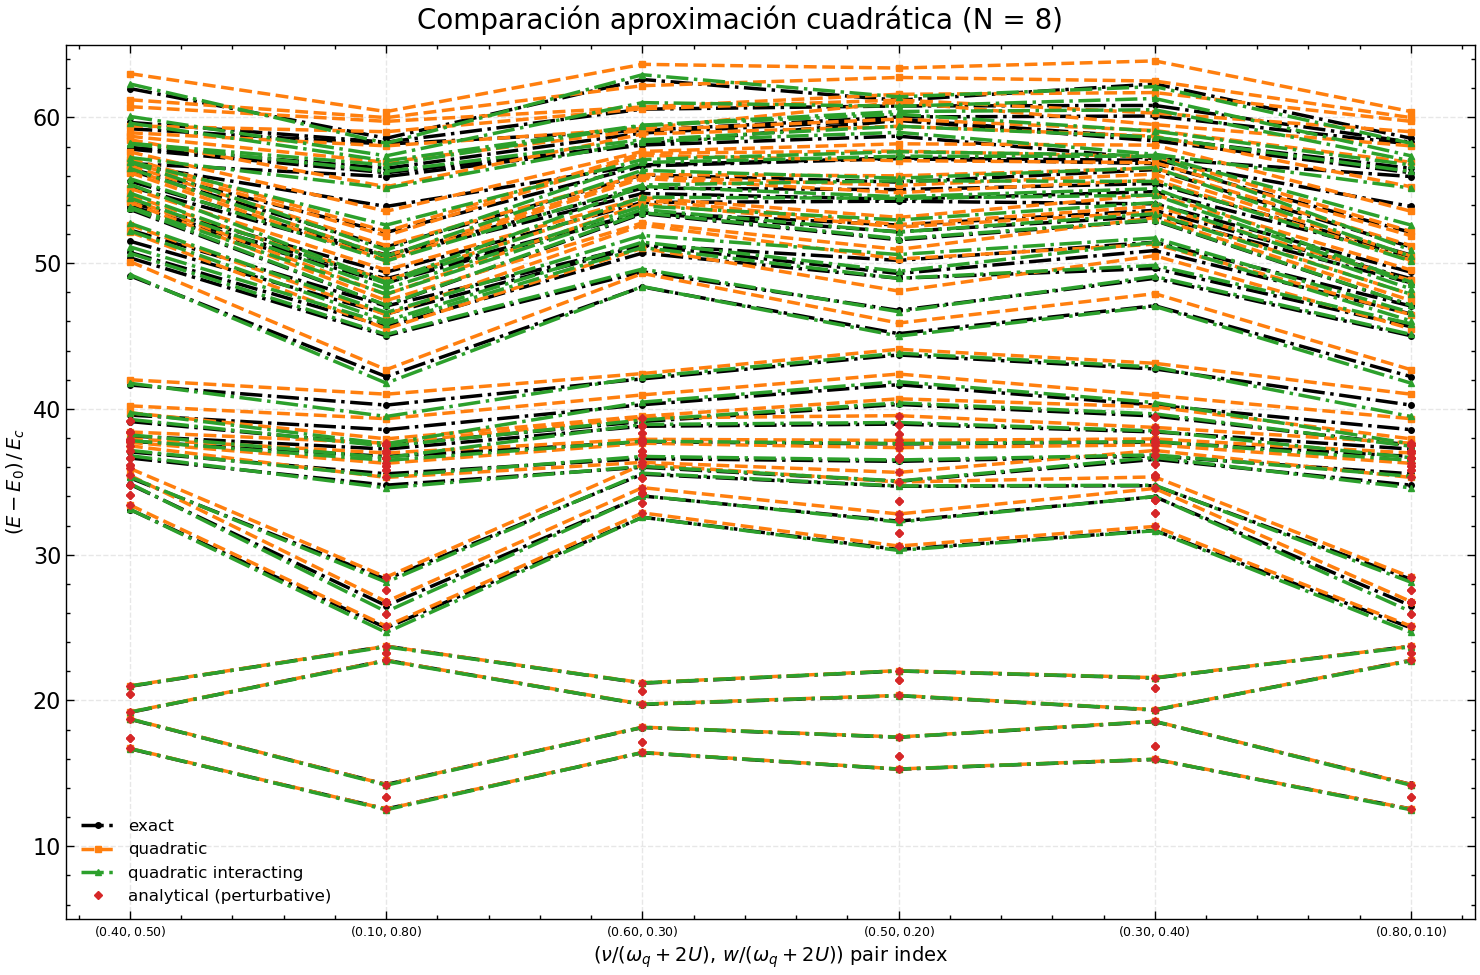

In [9]:
# Plot
# ------------------------------------------------------------------ #
fig, ax = plt.subplots(figsize=(15, 10))
fig.suptitle('Comparación aproximación cuadrática (N = 8)', fontsize=20)

styles = [
    {'color': '#000000',   'linestyle': '-.',  'linewidth': 2.5,
     'marker': 'o', 'markersize': 4, 'markevery': 1},
    {'color': '#ff7f0e',   'linestyle': '--',  'linewidth': 2.5,    # fix: invalid hex '#ff7e0e6c'
     'marker': 's', 'markersize': 4, 'markevery': 1},
    {'color': '#2ca02c',   'linestyle': '-.',  'linewidth': 2.5,    # fix: invalid hex '#2ca02cca'
     'marker': '^', 'markersize': 4, 'markevery': 1},
    {'color': '#d62728',   'linestyle': 'None',   'linewidth': 2.5,    # new: analytical
     'marker': 'D', 'markersize': 4, 'markevery': 1},
]
labels = ['exact', 'quadratic', 'quadratic interacting', 'analytical (perturbative)']

ax.set_xlabel(r'$({\nu}/{(\omega_q+2U)},\, {w}/{(\omega_q+2U)})$ pair index',
              fontsize=14)
ax.set_ylabel(r'$(E - E_0)\,/\,E_c$', fontsize=14)

# x-tick labels showing the actual (nu, w) ratios
ax.set_xticks(pair_indices)
ax.set_xticklabels(
    [rf'$({nf:.2f},{wf:.2f})$' for nf, wf in nu_w_pairs],
    fontsize=9
)

for energy_array, style, labl in zip(energy_matrix, styles, labels):
    ground = energy_array[:, 0]                      # shape (n_pairs,)
    for level_idx in range(energy_array.shape[1]):
        level = energy_array[:, level_idx]
        if level_idx == 0:
            ax.plot(pair_indices, np.zeros_like(level),
                    label=labl, **style)
        else:
            ax.plot(pair_indices, (level - ground) / E_c, **style)

ax.set_ylim(5.0, 65.0)
ax.grid(True, alpha=0.3, linestyle='--')
plt.legend(fontsize=12, framealpha=0.9)
fig.tight_layout()
plt.show()